**Importing Libraries and Loading Data**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data = pd.read_csv("Solardatanew_split.csv")
data.head(5)

,Timestamp,temperature,humidity,irradiation,RTD,pvVoltage,pvCurrent,Power_Generated
0,00:00.0,16.335964,92.397792,0.224350,25.034259,2.640770,5.399288,14.258278
1,05:00.0,16.289640,92.693440,0.327011,24.965698,2.645897,5.399017,14.285242
2,10:00.0,16.285664,93.123816,0.277451,24.944859,2.660332,5.398926,14.362932
3,15:00.0,16.281720,93.119280,0.376572,25.003318,2.148491,5.399197,11.600126
4,20:00.0,16.244652,93.557512,0.479233,24.979319,2.066124,5.399017,11.155038


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Dropping Unnecessary Columns**

In [ ]:
waste_1 = data.pop('Timestamp')

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1561 entries, 0 to 1560
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   temperature      1561 non-null   float64
 1   humidity         1561 non-null   float64
 2   irradiation      1561 non-null   float64
 3   RTD              1561 non-null   float64
 4   pvVoltage        1561 non-null   float64
 5   pvCurrent        1561 non-null   float64
 6   Power_Generated  1561 non-null   float64
dtypes: float64(7)
memory usage: 85.5 KB


**Exploratory Data Analysis**

In [ ]:
min_d = data['Power_Generated'].min()

In [ ]:
max_d=data['Power_Generated'].max()

In [ ]:
data["Power_Generated"].describe()

,Power_Generated
count,1561.000000
mean,190.154251
std,166.319933
min,8.016555
25%,11.829454
50%,278.411800
75%,302.613840
max,482.491720


**Data Visualization**

<Axes: xlabel='irradiation', ylabel='humidity'>

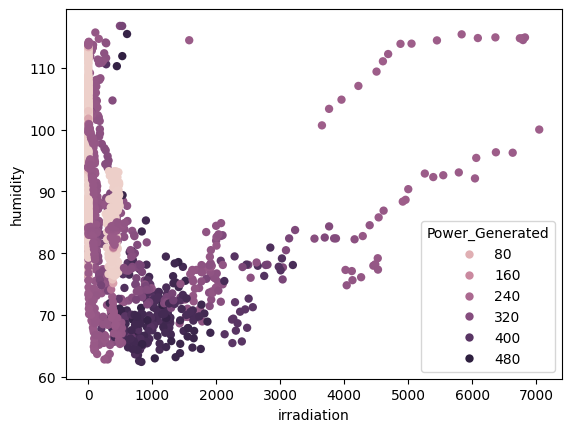

In [ ]:
sns.scatterplot(x="irradiation", y="humidity",
                 hue="Power_Generated",
                 sizes=(3, 15), linewidth=0,
                 data=data)

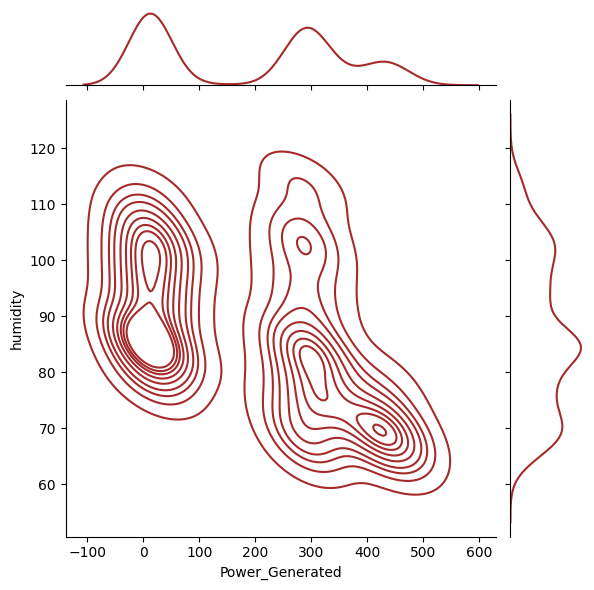

In [ ]:
sns.jointplot(x='Power_Generated',y='humidity',data = data, kind = 'kde' ,color = 'brown')

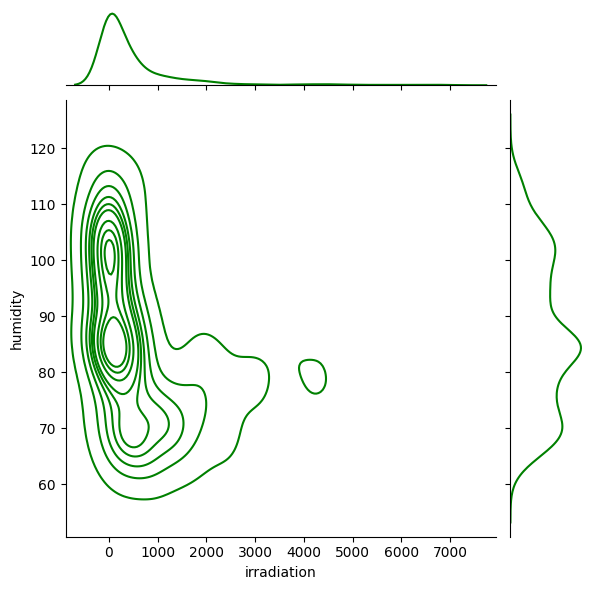

In [ ]:
sns.jointplot(x='irradiation',y='humidity',data = data, kind = 'kde' ,color = 'green')

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1561 entries, 0 to 1560
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   temperature      1561 non-null   float64
 1   humidity         1561 non-null   float64
 2   irradiation      1561 non-null   float64
 3   RTD              1561 non-null   float64
 4   pvVoltage        1561 non-null   float64
 5   pvCurrent        1561 non-null   float64
 6   Power_Generated  1561 non-null   float64
dtypes: float64(7)
memory usage: 85.5 KB


**Data Preprocessing**

In [ ]:
from sklearn import preprocessing
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

names = ["temperature","humidity","irradiation","RTD","pvVoltage","pvCurrent","Power_Generated"]
data[names] = scaler.fit_transform(data[names])

**Splitting Data into Training and Test Sets**

In [ ]:
X = data
Y = data.pop("Power_Generated")

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2)

In [ ]:
X.head(10)

,temperature,humidity,irradiation,RTD,pvVoltage,pvCurrent
0,0.123692,0.551456,0.000032,0.045133,0.013128,0.842876
1,0.122157,0.556891,0.000046,0.044163,0.013186,0.835318
2,0.122026,0.564804,0.000039,0.043868,0.013350,0.832780
3,0.121895,0.564720,0.000053,0.044695,0.007541,0.840338
4,0.120667,0.572777,0.000068,0.044356,0.006606,0.835318
5,0.119219,0.581021,0.000068,0.043072,0.006618,0.837772
6,0.117025,0.586509,0.000089,0.042675,0.006665,0.832780
7,0.117025,0.586480,0.000103,0.042546,0.006922,0.827732
8,0.116148,0.591880,0.000103,0.044017,0.007390,0.822712
9,0.116541,0.591851,0.000103,0.045287,0.008044,0.827732


In [ ]:
Y.head()

,Power_Generated
0,0.013155
1,0.013212
2,0.013376
3,0.007553
4,0.006615


In [ ]:
X.shape

(1561, 6)

**Building and Training the LSTM Model**

In [ ]:
%%time
import tensorflow as tf
import random

tf.random.set_seed(42)

model_2 = tf.keras.Sequential([tf.keras.layers.LSTM(300,activation='relu',return_sequences=True,input_shape=(6,1)),
                               tf.keras.layers.Dropout(0.2,seed=42),
                               tf.keras.layers.LSTM(200,activation='relu'),
                               tf.keras.layers.Dropout(0.2,seed=42),
                               tf.keras.layers.Dense(1)])

model_2.compile(loss='mae',
                optimizer= tf.keras.optimizers.Adam(learning_rate=0.005),
                metrics = ['mae'])

history_2 = model_2.fit(tf.expand_dims(X_train,axis=-1),Y_train,epochs=15)

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/15
39/39 ━━━━━━━━━━━━━━━━━━━━ 7s 77ms/step - loss: 0.2768 - mae: 0.2768
Epoch 2/15
39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - loss: 0.1047 - mae: 0.1047
Epoch 3/15
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 0.0803 - mae: 0.0803
Epoch 4/15
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 0.0565 - mae: 0.0565
Epoch 5/15
39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - loss: 0.0449 - mae: 0.0449
Epoch 6/15
39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - loss: 0.0433 - mae: 0.0433
Epoch 7/15
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - loss: 0.0383 - mae: 0.0383
Epoch 8/15
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 0.0313 - mae: 0.0313
Epoch 9/15
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 0.0325 - mae: 0.0325
Epoch 10/15
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 0.0304 - mae: 0.0304
Epoch 11/15
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - loss: 0.0327 - mae: 0.0327
Epoch 12/15
39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - loss: 0.0339 - mae: 0.0339
Epoch 13/15
39/39 ━━━━━━━━━━━━━━━━━━━

The model is evaluated on the test set to measure its performance.

In [ ]:
model_2.evaluate(X_test,Y_test)

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0227 - mae: 0.0227


[0.023352336138486862, 0.023352336138486862]

**Visualizing Training Performance**

Text(0, 0.5, 'Mean Absoulte Error')

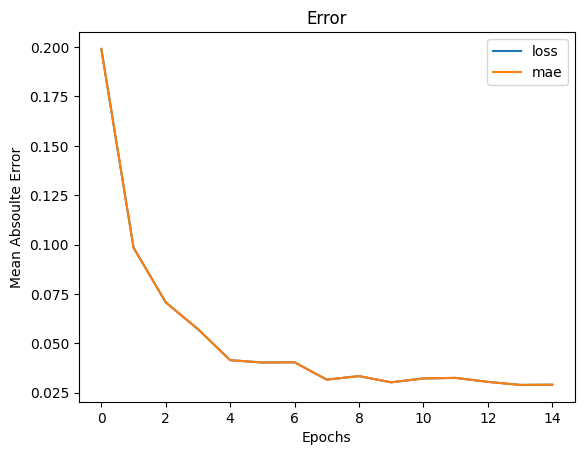

In [ ]:
pd.DataFrame(history_2.history).plot()
plt.title("Error")
plt.xlabel("Epochs")
plt.ylabel("Mean Absoulte Error")

The model makes predictions on the test data.

In [ ]:
pred_2 = model_2.predict(Y_test)

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step


In [ ]:
pred_2.shape

(313, 1)

In [ ]:
pred_2

array([[ 0.23086672],
       [-0.00522527],
       [-0.00524708],
       [ 0.16075742],
       [-0.00530459],
       [ 0.13744359],
       [ 0.13181324],
       [-0.00527418],
       [ 0.12281132],
       [ 0.13796249],
       [-0.00532624],
       [ 0.12966108],
       [ 0.12945928],
       [-0.00531792],
       [-0.00526218],
       [ 0.12905565],
       [-0.00529001],
       [-0.00531972],
       [ 0.12508911],
       [ 0.13726972],
       [ 0.12792155],
       [ 0.13473493],
       [-0.00535954],
       [ 0.22201592],
       [ 0.14295751],
       [-0.00529436],
       [-0.00505724],
       [ 0.12642384],
       [-0.00533185],
       [-0.00518382],
       [ 0.16487151],
       [ 0.1381698 ],
       [ 0.12686308],
       [ 0.12222876],
       [ 0.13188039],
       [ 0.16258515],
       [ 0.13025747],
       [ 0.16146198],
       [-0.00524742],
       [-0.00531527],
       [-0.0052017 ],
       [ 0.13683526],
       [-0.00521084],
       [ 0.21264601],
       [-0.00516982],
       [-0

In [ ]:
#normalized_d = pred_2
#final = normalized_d * (max_d - min_d) + min_d
#final

Post-processing Predictions.
The predictions are converted back to the original scale using max_d and min_d.

In [ ]:
final_power = pred_2 * (max_d - min_d)+ min_d
final_power

array([[117.557076 ],
       [  5.5372934],
       [  5.526946 ],
       [ 84.29196  ],
       [  5.499659 ],
       [ 73.230125 ],
       [ 70.55866  ],
       [  5.514086 ],
       [ 66.287476 ],
       [ 73.47633  ],
       [  5.4893847],
       [ 69.53751  ],
       [ 69.441765 ],
       [  5.493333 ],
       [  5.5197797],
       [ 69.25025  ],
       [  5.5065784],
       [  5.4924793],
       [ 67.368225 ],
       [ 73.14763  ],
       [ 68.71215  ],
       [ 71.94493  ],
       [  5.473588 ],
       [113.35759  ],
       [ 75.846344 ],
       [  5.504511 ],
       [  5.6170197],
       [ 68.001526 ],
       [  5.486723 ],
       [  5.55696  ],
       [ 86.243996 ],
       [ 73.57469  ],
       [ 68.20993  ],
       [ 66.01106  ],
       [ 70.59052  ],
       [ 85.15917  ],
       [ 69.82049  ],
       [ 84.62625  ],
       [  5.526786 ],
       [  5.4945908],
       [  5.548477 ],
       [ 72.94149  ],
       [  5.544142 ],
       [108.911804 ],
       [  5.5636034],
       [  

In [ ]:
final_power.shape

(313, 1)

**Correlation matrix**

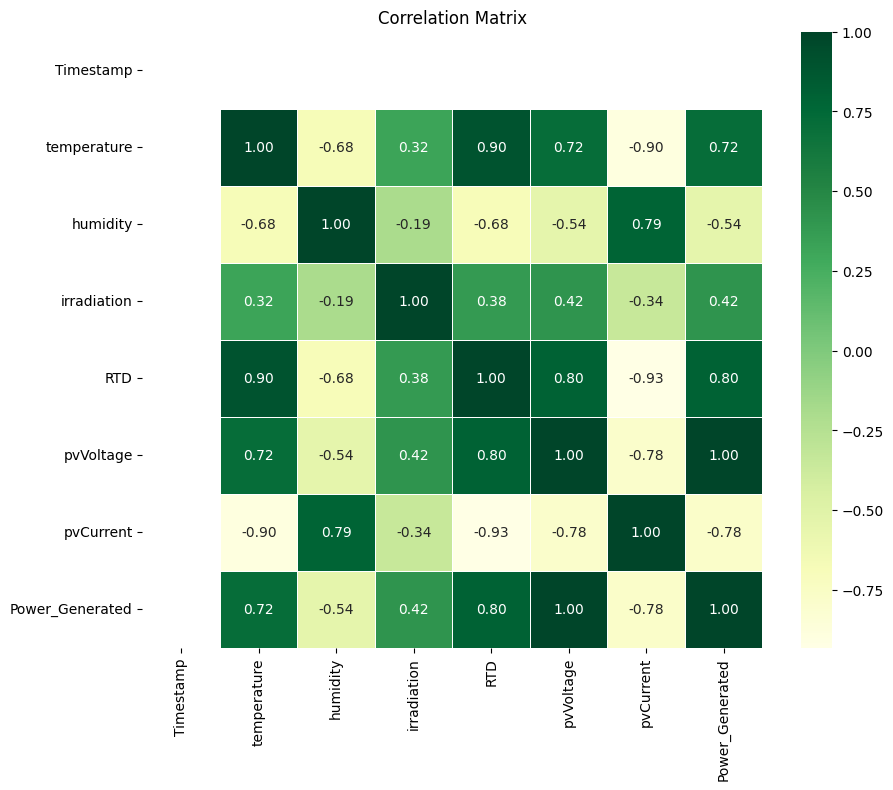

In [ ]:
# Load the dataset
data = pd.read_csv("Solardatanew_split.csv")

# Identify columns with object (string) dtype
object_columns = data.select_dtypes(include=['object']).columns

# Attempt to convert object columns to numeric, handling errors
for col in object_columns:
    try:
        data[col] = pd.to_numeric(data[col], errors='coerce')
    except ValueError:
        print(f"Could not convert column {col} to numeric. Further inspection needed.")

# Compute the correlation matrix
corr_matrix = data.corr()

# Plot the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='YlGn', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

  Timestamp  temperature   humidity  irradiation        RTD  pvVoltage  \
0   00:00.0    16.335964  92.397792     0.224350  25.034259   2.640770   
1   05:00.0    16.289640  92.693440     0.327011  24.965698   2.645897   
2   10:00.0    16.285664  93.123816     0.277451  24.944859   2.660332   
3   15:00.0    16.281720  93.119280     0.376572  25.003318   2.148491   
4   20:00.0    16.244652  93.557512     0.479233  24.979319   2.066124   

   pvCurrent  Power_Generated  
0   5.399288        14.258278  
1   5.399017        14.285242  
2   5.398926        14.362932  
3   5.399197        11.600126  
4   5.399017        11.155038  


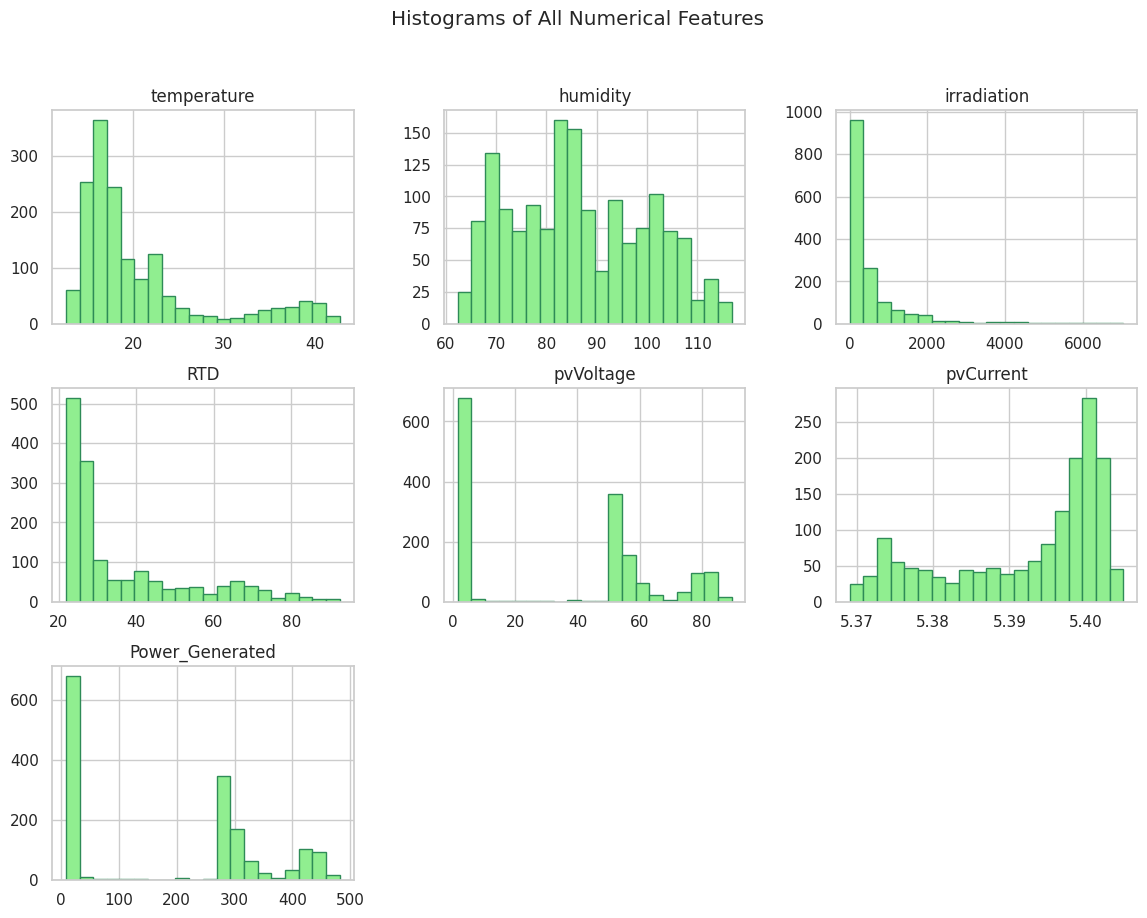

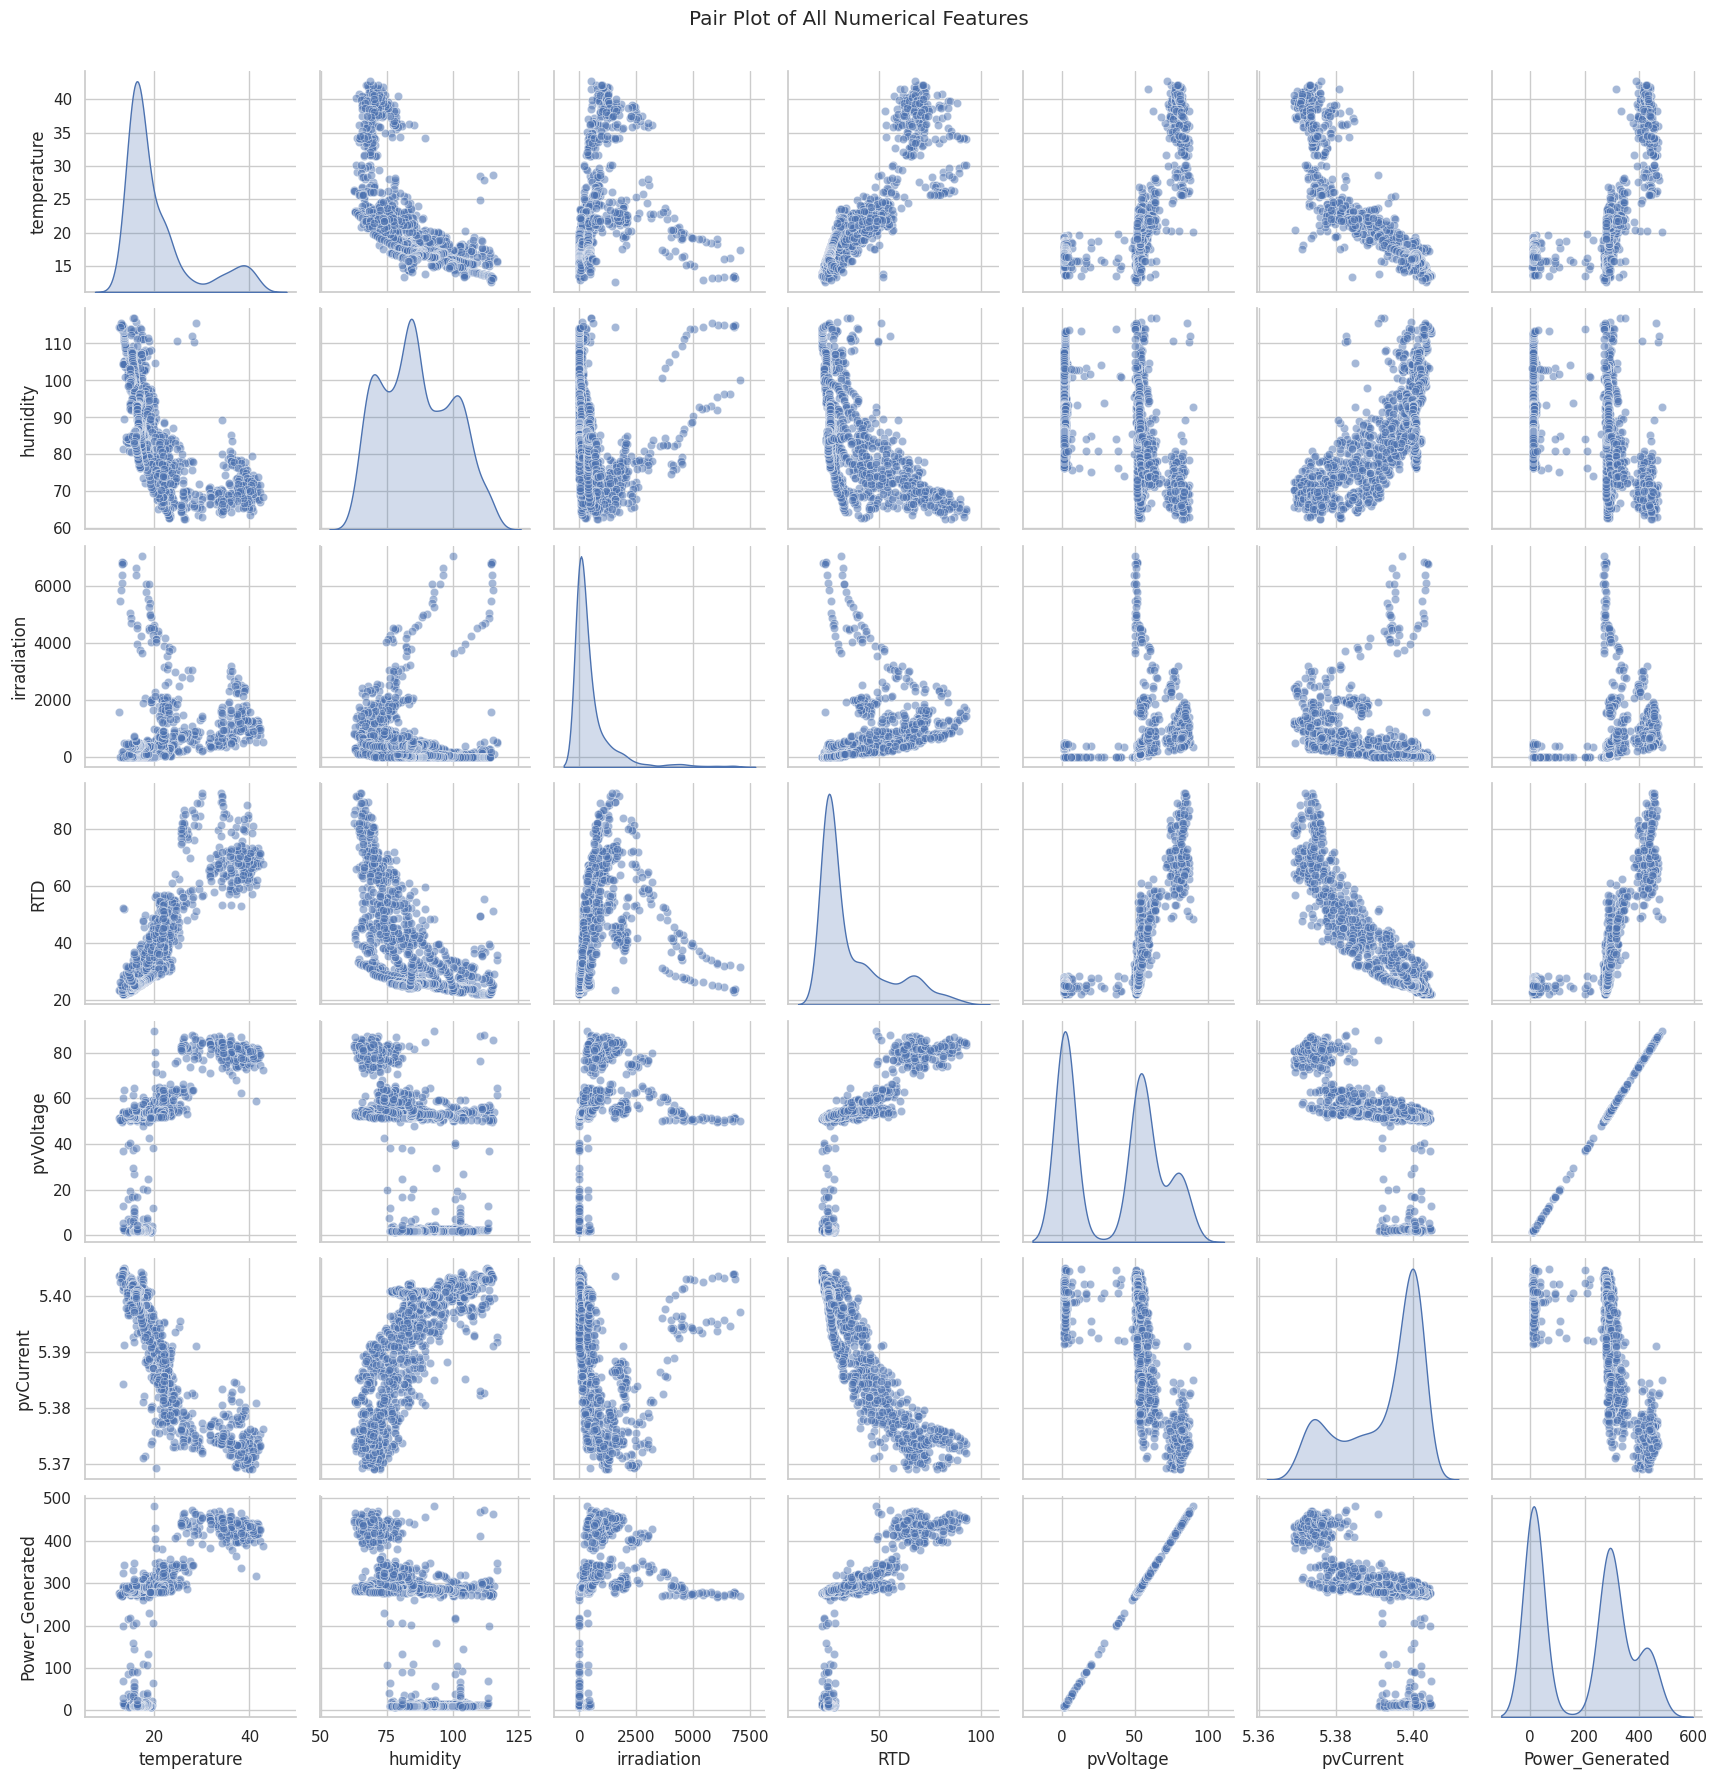

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
data = pd.read_csv('Solardatanew_split.csv')

# Display the first few rows to understand the data structure
print(data.head())

# Set the aesthetic style of the plots
sns.set(style="whitegrid")

# 1. Histogram for each numerical feature
data.hist(figsize=(14, 10), bins=20, color='lightgreen', edgecolor='seagreen')
plt.suptitle('Histograms of All Numerical Features')
plt.show()


# 3. Pairplot to visualize relationships between numerical features
sns.pairplot(data, diag_kind='kde', plot_kws={'alpha': 0.5})
plt.suptitle('Pair Plot of All Numerical Features', y=1.02)
plt.show()
